# CART Synthesizer Example

This notebook demonstrates how to use the CART (Classification and Regression Trees) synthesizer from the `stg` library to generate synthetic tabular data.

CART is a tree-based method that learns conditional dependencies between columns to generate realistic synthetic data.

## Setup and Imports

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to the path
sys.path.insert(0, os.path.abspath('../src'))

from stg.tableSynthesizer import TableSynthesizer

/home/xiaofeng/anaconda3/envs/table-synthesizers/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Create Sample Data

Let's create a sample dataset with different data types to demonstrate CART's capabilities.

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Create a sample dataset with mixed data types
n_samples = 1000

df = pd.DataFrame({
    'age': np.random.randint(18, 80, n_samples),
    'income': np.random.lognormal(10, 0.5, n_samples),
    'education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_samples),
    'city': np.random.choice(['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'], n_samples),
    'married': np.random.choice([True, False], n_samples),
    'credit_score': np.random.randint(300, 850, n_samples)
})

# Add some correlation between variables
# Higher education tends to correlate with higher income
education_income_boost = df['education'].map({
    'High School': 1.0,
    'Bachelor': 1.3,
    'Master': 1.6,
    'PhD': 2.0
})
df['income'] = df['income'] * education_income_boost

print(f"Original dataset shape: {df.shape}")
print("\nDataset overview:")
print(df.head())
print("\nData types:")
print(df.dtypes)

Original dataset shape: (1000, 6)

Dataset overview:
   age        income education         city  married  credit_score
0   56  56871.701715  Bachelor     New York    False           785
1   69  20403.693512  Bachelor  Los Angeles    False           565
2   46  78426.182933       PhD     New York    False           723
3   32  36520.968949       PhD      Phoenix    False           427
4   60  31134.574590       PhD      Houston    False           537

Data types:
age               int64
income          float64
education        object
city             object
married            bool
credit_score      int64
dtype: object


## Visualize Original Data

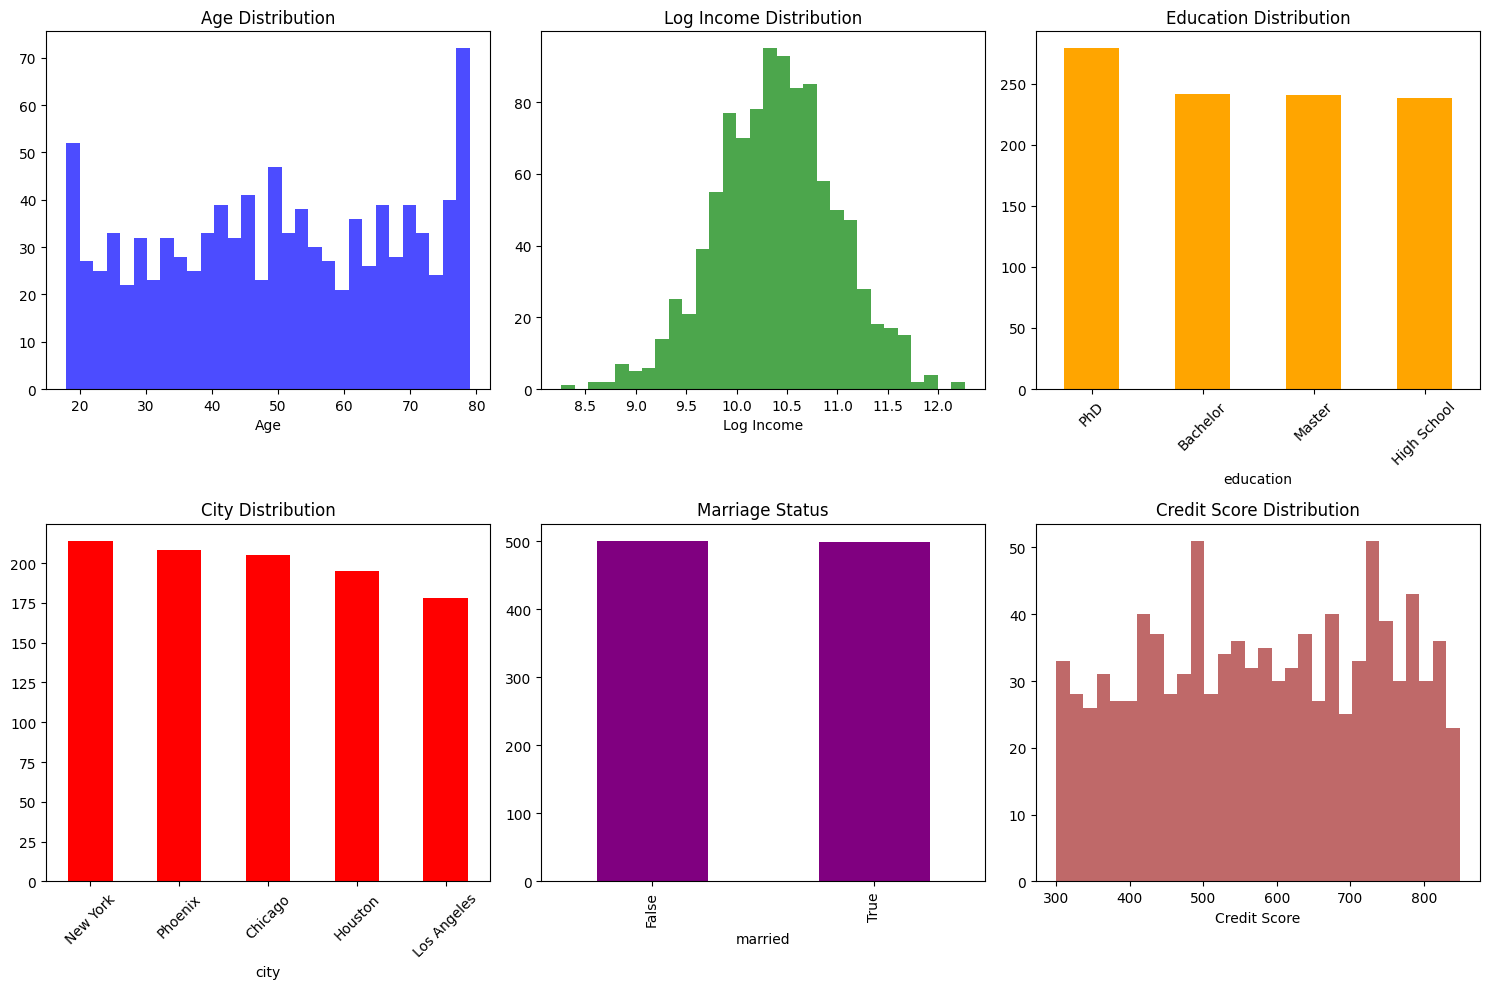

In [3]:
# Create visualizations of the original data
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Age distribution
axes[0, 0].hist(df['age'], bins=30, alpha=0.7, color='blue')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')

# Income distribution (log scale)
axes[0, 1].hist(np.log(df['income']), bins=30, alpha=0.7, color='green')
axes[0, 1].set_title('Log Income Distribution')
axes[0, 1].set_xlabel('Log Income')

# Education distribution
df['education'].value_counts().plot(kind='bar', ax=axes[0, 2], color='orange')
axes[0, 2].set_title('Education Distribution')
axes[0, 2].tick_params(axis='x', rotation=45)

# City distribution
df['city'].value_counts().plot(kind='bar', ax=axes[1, 0], color='red')
axes[1, 0].set_title('City Distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

# Marriage distribution
df['married'].value_counts().plot(kind='bar', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Marriage Status')

# Credit score distribution
axes[1, 2].hist(df['credit_score'], bins=30, alpha=0.7, color='brown')
axes[1, 2].set_title('Credit Score Distribution')
axes[1, 2].set_xlabel('Credit Score')

plt.tight_layout()
plt.show()

## Initialize and Train CART Synthesizer

CART supports several configuration parameters:
- `max_depth`: Maximum depth of decision trees (None for unlimited)
- `random_state`: Random seed for reproducibility

In [4]:
# Configure CART synthesizer
config = {
    "max_depth": 10,  # Limit tree depth to prevent overfitting
    "random_state": 42
}

# Initialize synthesizer
synthesizer = TableSynthesizer('CART', config)

print("CART synthesizer initialized successfully!")

CART synthesizer initialized successfully!


In [5]:
# Train the synthesizer on our data
print("Training CART synthesizer...")
synthesizer.fit(df)
print("Training completed!")

Training CART synthesizer...
CART: stored 1000 training samples
Numeric columns: ['age', 'income', 'married', 'credit_score']
Categorical columns: ['education', 'city']
Training completed!


## Generate Synthetic Data

Now let's generate synthetic data using our trained CART model.

In [6]:
# Generate synthetic samples as DataFrame
n_synthetic = 500
synthetic_df = synthesizer.sample(n=n_synthetic, return_dataframe=True)

print(f"Generated {len(synthetic_df)} synthetic samples")
print("\nSynthetic data overview:")
print(synthetic_df.head())
print("\nSynthetic data types:")
print(synthetic_df.dtypes)

Generated 500 synthetic samples

Synthetic data overview:
    age        income    education      city  married  credit_score
0  44.0  27803.879455  High School  New York      1.0           571
1  47.0  33572.207487  High School   Chicago      1.0           561
2  45.0  13790.607056       Master   Phoenix      0.0           629
3  75.0  74097.968887          PhD   Houston      0.0           842
4  45.0  37359.350588       Master  New York      1.0           312

Synthetic data types:
age             float64
income          float64
education        object
city             object
married         float64
credit_score      int64
dtype: object


## Compare Original vs Synthetic Data

Let's compare the distributions of original and synthetic data to evaluate quality.

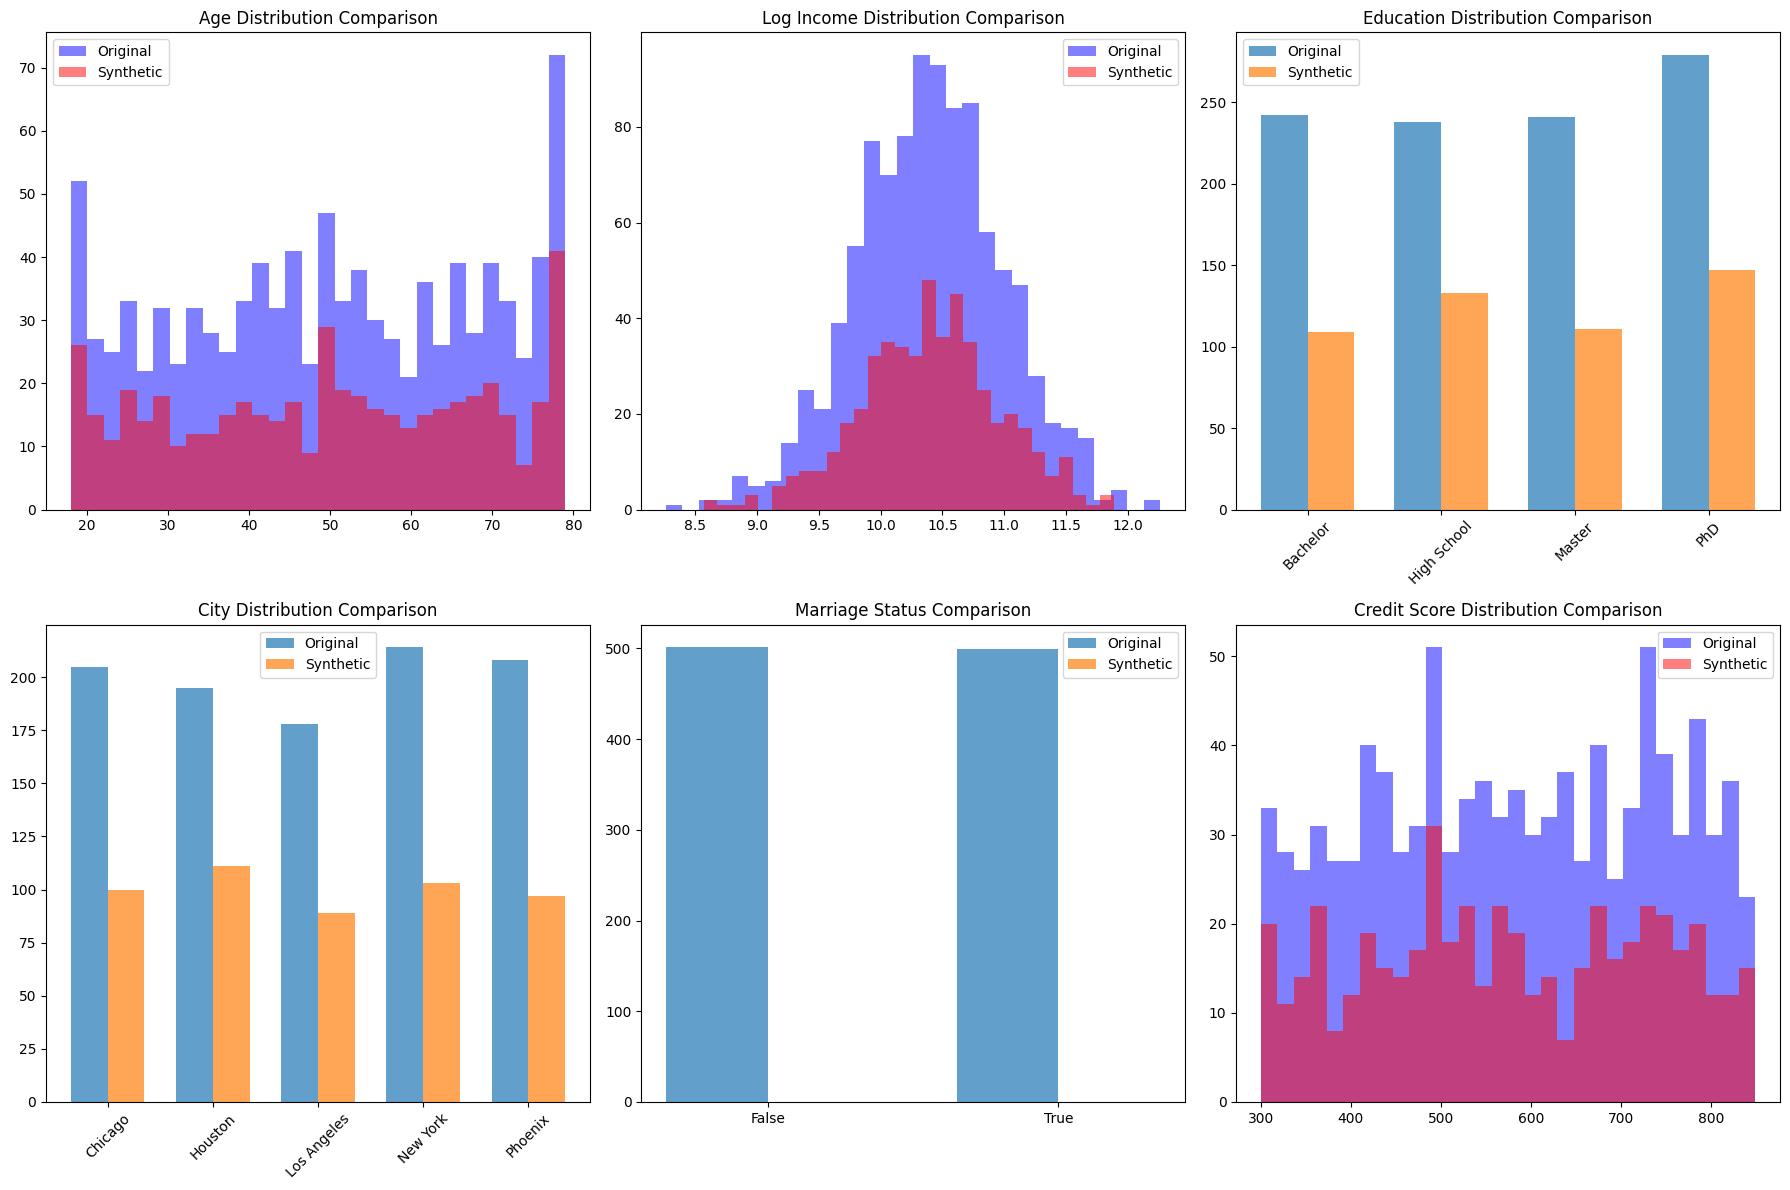

In [7]:
# Compare distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Age comparison
axes[0, 0].hist(df['age'], bins=30, alpha=0.5, label='Original', color='blue')
axes[0, 0].hist(synthetic_df['age'], bins=30, alpha=0.5, label='Synthetic', color='red')
axes[0, 0].set_title('Age Distribution Comparison')
axes[0, 0].legend()

# Income comparison (log scale)
axes[0, 1].hist(np.log(df['income']), bins=30, alpha=0.5, label='Original', color='blue')
axes[0, 1].hist(np.log(synthetic_df['income']), bins=30, alpha=0.5, label='Synthetic', color='red')
axes[0, 1].set_title('Log Income Distribution Comparison')
axes[0, 1].legend()

# Education comparison
education_orig = df['education'].value_counts().sort_index()
education_synth = synthetic_df['education'].value_counts().reindex(education_orig.index, fill_value=0)
x = np.arange(len(education_orig))
width = 0.35
axes[0, 2].bar(x - width/2, education_orig.values, width, label='Original', alpha=0.7)
axes[0, 2].bar(x + width/2, education_synth.values, width, label='Synthetic', alpha=0.7)
axes[0, 2].set_title('Education Distribution Comparison')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(education_orig.index, rotation=45)
axes[0, 2].legend()

# City comparison
city_orig = df['city'].value_counts().sort_index()
city_synth = synthetic_df['city'].value_counts().reindex(city_orig.index, fill_value=0)
x = np.arange(len(city_orig))
axes[1, 0].bar(x - width/2, city_orig.values, width, label='Original', alpha=0.7)
axes[1, 0].bar(x + width/2, city_synth.values, width, label='Synthetic', alpha=0.7)
axes[1, 0].set_title('City Distribution Comparison')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(city_orig.index, rotation=45)
axes[1, 0].legend()

# Marriage comparison
married_orig = df['married'].value_counts().sort_index()
married_synth = synthetic_df['married'].value_counts().reindex(married_orig.index, fill_value=0)
x = np.arange(len(married_orig))
axes[1, 1].bar(x - width/2, married_orig.values, width, label='Original', alpha=0.7)
axes[1, 1].bar(x + width/2, married_synth.values, width, label='Synthetic', alpha=0.7)
axes[1, 1].set_title('Marriage Status Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels([str(x) for x in married_orig.index])
axes[1, 1].legend()

# Credit score comparison
axes[1, 2].hist(df['credit_score'], bins=30, alpha=0.5, label='Original', color='blue')
axes[1, 2].hist(synthetic_df['credit_score'], bins=30, alpha=0.5, label='Synthetic', color='red')
axes[1, 2].set_title('Credit Score Distribution Comparison')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

## Statistical Summary Comparison

In [8]:
# Compare statistical summaries
print("ORIGINAL DATA SUMMARY:")
print(df.describe())
print("\n" + "="*60)
print("SYNTHETIC DATA SUMMARY:")
print(synthetic_df.describe())

ORIGINAL DATA SUMMARY:
               age         income  credit_score
count  1000.000000    1000.000000   1000.000000
mean     49.857000   38846.441034    580.114000
std      18.114267   24768.788464    155.436436
min      18.000000    3869.634717    300.000000
25%      35.000000   21768.402006    447.000000
50%      50.000000   32864.930328    581.000000
75%      66.000000   48120.894997    721.000000
max      79.000000  211955.297210    849.000000

SYNTHETIC DATA SUMMARY:
              age         income     married  credit_score
count  500.000000     500.000000  500.000000    500.000000
mean    49.818000   38251.569043    0.528000    575.632000
std     18.258028   22402.345806    0.499715    154.558978
min     18.000000    5261.388389    0.000000    300.000000
25%     34.750000   22740.204879    0.000000    454.000000
50%     50.000000   33443.706017    1.000000    567.500000
75%     66.000000   46058.405576    1.000000    713.250000
max     79.000000  145522.547128    1.000000    

## Correlation Analysis

Let's check if CART preserved the correlations between variables.

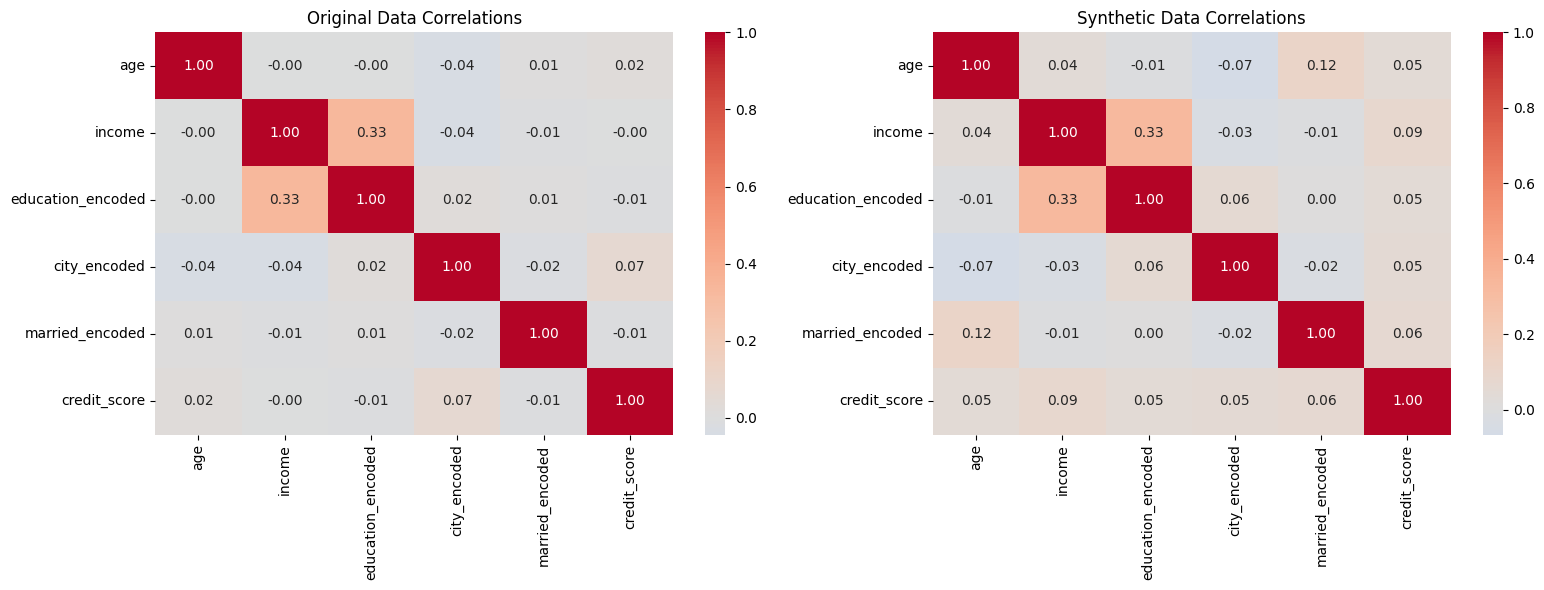


Mean absolute correlation difference: 0.035


In [9]:
# Prepare data for correlation analysis (convert categorical to numeric)
def prepare_for_correlation(df):
    corr_df = df.copy()
    
    # Encode categorical variables
    corr_df['education_encoded'] = pd.Categorical(corr_df['education']).codes
    corr_df['city_encoded'] = pd.Categorical(corr_df['city']).codes
    corr_df['married_encoded'] = corr_df['married'].astype(int)
    
    # Select numeric columns for correlation
    numeric_cols = ['age', 'income', 'education_encoded', 'city_encoded', 'married_encoded', 'credit_score']
    return corr_df[numeric_cols]

# Calculate correlations
orig_corr = prepare_for_correlation(df).corr()
synth_corr = prepare_for_correlation(synthetic_df).corr()

# Plot correlation matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(orig_corr, annot=True, cmap='coolwarm', center=0, ax=ax1, fmt='.2f')
ax1.set_title('Original Data Correlations')

sns.heatmap(synth_corr, annot=True, cmap='coolwarm', center=0, ax=ax2, fmt='.2f')
ax2.set_title('Synthetic Data Correlations')

plt.tight_layout()
plt.show()

# Calculate correlation difference
corr_diff = np.abs(orig_corr - synth_corr)
print(f"\nMean absolute correlation difference: {corr_diff.values[np.triu_indices_from(corr_diff, k=1)].mean():.3f}")

## Generate Different Sample Sizes

CART can generate any number of samples. Let's demonstrate this capability.

In [10]:
# Generate different sample sizes
sample_sizes = [100, 500, 1000, 2000]

for size in sample_sizes:
    samples = synthesizer.sample(n=size, return_dataframe=True)
    print(f"Generated {len(samples)} samples (requested {size})")
    
    # Quick quality check - verify column types are preserved
    type_match = all(samples.dtypes == synthetic_df.dtypes)
    print(f"Data types preserved: {type_match}")
    print()

Generated 100 samples (requested 100)
Data types preserved: True

Generated 500 samples (requested 500)
Data types preserved: True

Generated 1000 samples (requested 1000)
Data types preserved: True

Generated 2000 samples (requested 2000)
Data types preserved: True



## Advanced Usage: Tensor Output

CART also supports tensor output for integration with other machine learning workflows.

In [11]:
# Generate samples as tensor
tensor_samples = synthesizer.sample(n=100, return_dataframe=False)

print(f"Tensor shape: {tensor_samples.shape}")
print(f"Tensor dtype: {tensor_samples.dtype}")
print(f"First few tensor samples:")
print(tensor_samples[:5])

Tensor shape: torch.Size([100, 6])
Tensor dtype: torch.float32
First few tensor samples:
tensor([[4.5000e+01, 1.5199e+04, 2.0000e+00, 3.0000e+00, 0.0000e+00, 5.7100e+02],
        [4.7000e+01, 3.9091e+04, 3.0000e+00, 0.0000e+00, 1.0000e+00, 5.6100e+02],
        [7.1000e+01, 1.2492e+04, 2.0000e+00, 2.0000e+00, 0.0000e+00, 6.2900e+02],
        [7.5000e+01, 7.4098e+04, 3.0000e+00, 1.0000e+00, 1.0000e+00, 8.4200e+02],
        [3.9000e+01, 3.2839e+04, 0.0000e+00, 0.0000e+00, 1.0000e+00, 3.1200e+02]])


## Summary

This example demonstrated:

1. **Data Preparation**: Creating a mixed-type dataset with correlations
2. **CART Configuration**: Setting up the synthesizer with appropriate parameters
3. **Training**: Fitting the CART model on the original data
4. **Generation**: Creating synthetic samples in both DataFrame and tensor formats
5. **Evaluation**: Comparing distributions and correlations between original and synthetic data

### Key Features of CART Synthesizer:
- **Mixed Data Types**: Handles numeric, categorical, and boolean columns
- **DataFrame-Only**: Designed specifically for DataFrame input (not DataLoader)
- **Configurable**: Supports max_depth and random_state parameters
- **Flexible Output**: Can return either DataFrame or tensor format
- **Scalable**: Can generate any number of synthetic samples

### When to Use CART:
- When you have mixed-type tabular data
- When you need an interpretable, tree-based approach
- When working with smaller to medium-sized datasets
- When you want to preserve conditional dependencies between variables

CART is particularly effective for datasets where tree-based models perform well and where interpretability of the generation process is important.